# Stage 2 — R-peak Realignment

## What this notebook does

After the initial 12-lead reconstruction (Stage 1), a small systematic timing shift can exist between the Lead-II reference R-peaks and the R-peaks re-detected on each recovered lead signal. This notebook computes that shift **δ** and uses it to realign the beat template, producing a corrected recovery.

### Math (from the paper)

For lead $\ell$, let $\mathcal{R}^\ell = \{r^\ell_1,\ldots,r^\ell_K\}$ be the R-peaks re-detected on the recovered signal, and $\mathcal{R} = \{r_1,\ldots,r_K\}$ be the Lead-II reference peaks. The per-beat correction offset is:

$$\delta = \frac{1}{K}\sum_{k=1}^{K}\bigl(r^\ell_k - r_k\bigr)$$

The refined peak locations $\hat{r}_k = r_k + \delta$ are then fed back into the template recovery.

### Critical constraint

**δ must be estimated only from the observed (real) window of each lead** — not from the imputed region — because R-peaks in the imputed region were placed by the Stage-1 template and carry no independent timing information.

### Data sources

| Source | Content | Format |
|--------|---------|--------|
| `FIDUCIAL_DIR/<subfolder>/<record>.mat` | Lead-II R-peaks from Stage 1 (OSET) | `.mat`, `position.R`, **1-based** MATLAB indices |
| `FIDUCIAL_OUT_DIR/<subfolder>/<record>_fiducial.csv` | R-peaks on every recovered lead (OSET CSV) | CSV, `R` column, **1-based** global sample index |
| `RECOVERED_MAT_DIR/<subfolder>/<record>.mat` | Recovered ECG signals | `.mat`, `ecg` shape `(N, leads)` |

### Output

- Per-record `delta` values saved to `DELTA_OUT_DIR/<subfolder>/<record>_delta.npz`
- Realigned recovered signals saved to `REALIGNED_DIR/<subfolder>/<record>.npy` — same shape as Stage-1 `.npy` files
- Summary CSV: `rpeak_delta_summary.csv`

## 1. Imports & Configuration

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import scipy.io as sio
from pathlib import Path
from tqdm import tqdm

# ── Paths ─────────────────────────────────────────────────────────────────
# Stage-1 Lead-II fiducials (OSET .mat files — original PTB-XL processing)
FIDUCIAL_DIR      = "/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3"

# Stage-2 fiducial CSVs (from extract_fiducials_batch.m on recovered signals)
FIDUCIAL_OUT_DIR  = "/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_recovered_3"

# Stage-1b recovered .mat files (needed to re-run the template)
RECOVERED_MAT_DIR = "/Users/sinahassannia/Desktop/ecg_lead_cover2/recovered_mat3"

# Outputs
DELTA_OUT_DIR     = "/Users/sinahassannia/Desktop/ecg_lead_cover2/rpeak_deltas3"
REALIGNED_DIR     = "/Users/sinahassannia/Desktop/ecg_lead_cover2/realigned_ecg3"
SUMMARY_CSV       = "/Users/sinahassannia/Desktop/ecg_lead_cover2/rpeak_delta_summary3.csv"

# Sampling rate (PTB-XL high-res)
FS = 500

# Lead order — must match Stage 1
ALL_LEADS = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

for d in [DELTA_OUT_DIR, REALIGNED_DIR]:
    os.makedirs(d, exist_ok=True)

print("Paths configured.")
print(f"  Stage-1 Lead-II fiducials : {FIDUCIAL_DIR}")
print(f"  Stage-2 recovered fiducials: {FIDUCIAL_OUT_DIR}")
print(f"  Recovered .mat files       : {RECOVERED_MAT_DIR}")
print(f"  Output deltas              : {DELTA_OUT_DIR}")
print(f"  Realigned signals          : {REALIGNED_DIR}")

Paths configured.
  Stage-1 Lead-II fiducials : /Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3
  Stage-2 recovered fiducials: /Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_recovered_3
  Recovered .mat files       : /Users/sinahassannia/Desktop/ecg_lead_cover2/recovered_mat3
  Output deltas              : /Users/sinahassannia/Desktop/ecg_lead_cover2/rpeak_deltas3
  Realigned signals          : /Users/sinahassannia/Desktop/ecg_lead_cover2/realigned_ecg3


## 2. Core Helper Functions

In [2]:
# ── 2a. Observed window (mirrors Stage 1 exactly) ─────────────────────────

def get_observed_window(lead: str, fs: int = 500):
    """
    Return (obs_start, obs_end) — 0-based sample indices, exclusive end.
    These are the samples that contain REAL (non-imputed) signal.
    """
    lead = lead.upper().replace('AVR','aVR').replace('AVL','aVL').replace('AVF','aVF')
    if lead == 'II':
        return (0, int(10 * fs))                    # fully observed
    elif lead in ('I', 'III'):
        return (0, int(2.5 * fs))                   # 0 – 2.5 s
    elif lead in ('aVR', 'aVL', 'aVF'):
        return (int(2.5 * fs), int(5 * fs))         # 2.5 – 5 s
    elif lead in ('V1', 'V2', 'V3'):
        return (int(5 * fs), int(7.5 * fs))         # 5 – 7.5 s
    elif lead in ('V4', 'V5', 'V6'):
        return (int(7.5 * fs), int(10 * fs))        # 7.5 – 10 s
    else:
        raise ValueError(f"Unknown lead: {lead}")


# # ── 2b. Load Lead-II R-peaks from Stage-1 OSET .mat ────────────────────── changed 

# def load_leadII_rpeaks(record_name: str, fiducial_dir: str) -> np.ndarray:
#     """
#     Load the Lead-II R-peak sample indices produced by OSET in Stage 1.

#     Args:
#         record_name : e.g. '00001_hr'
#         fiducial_dir: root of the OSET results tree

#     Returns:
#         r_peaks : 1D int array, **0-based** Python indices
#     """
#     record_id  = int(record_name.split('_')[0])
#     folder_id  = (record_id - 1) // 1000 * 1000
#     folder_str = f"{folder_id:05d}"
#     mat_path   = os.path.join(fiducial_dir, folder_str, f"{record_name}.mat")

#     mat = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
#     pos = mat['position']
#     r   = np.atleast_1d(getattr(pos, 'R')).flatten().astype(float)
#     r   = r - 1          # MATLAB 1-based → Python 0-based
#     return r.astype(int)

# ── 2d. load_fiducials ─────────────────────────────────────────────────────

def load_leadII_rpeaks(record_name: str, fiducial_dir: str) -> np.ndarray:
    """
    Load Lead II R-peak sample indices from fiducial .mat file.

    Args:
        record_name : e.g. '00001_hr'
        fiducial_dir: root of the fiducial results tree

    Returns:
        r_peaks : 1D int array, **0-based** Python indices
    """
    record_id  = int(record_name.split('_')[0])
    folder_id  = (record_id - 1) // 1000 * 1000
    folder_str = f"{folder_id:05d}"
    mat_path   = os.path.join(fiducial_dir, folder_str, f"{record_name}_fiducial.mat")

    mat        = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    lead_names = list(mat['lead_names'])
    lead_idx   = lead_names.index('II')
    pos        = mat['ecg_fiducial_position'][lead_idx]

    r = np.atleast_1d(getattr(pos, 'R')).flatten().astype(float)
    r = r - 1   # MATLAB 1-based → Python 0-based
    return r.astype(int)

# ── 2c. Parse OSET fiducial CSV (fixed for actual OSET format) ───────────
#
# OSET's ecg_fiducial_handle_csv writes a 3-row header before data:
#   Row 0: human-readable column descriptions  (skip)
#   Row 1: units                               (skip)
#   Row 2: scale factors                       (skip)
#   Row 3+: actual fiducial data
#
# lead_num is a 1-based integer (1=I, 2=II, ..., 12=V6).
# All sample indices are 1-based (MATLAB convention).

OSET_CSV_COLUMNS = [
    'lead_num', 'p_on', 'p', 'p_off',
    'qrs_on', 'rpeak_indexes', 'qrs_off',
    't_on', 't', 't_off',
    'p_on_amp', 'p_amp', 'p_off_amp',
    'qrs_on_amp', 'r_amp', 'qrs_off_amp',
    't_on_amp', 't_amp', 't_off_amp'
]

def read_fiducial_csv(csv_path: str, lead: str, all_leads: list) -> pd.DataFrame:
    """
    Parse one lead's rows from an OSET fiducial CSV.

    Args:
        csv_path  : path to the _fiducial.csv file
        lead      : lead name, e.g. 'I', 'aVR', 'V1'
        all_leads : ordered list of all lead names (defines 1-based numbering)

    Returns:
        DataFrame with columns matching OSET_CSV_COLUMNS, numeric dtypes,
        filtered to the requested lead.  Sample indices are converted to
        0-based Python integers.
    """
    lead_num = all_leads.index(lead) + 1   # 1-indexed

    df = pd.read_csv(csv_path, header=None, skiprows=3,
                     names=OSET_CSV_COLUMNS)

    # Coerce lead_num to numeric (drops header artefacts / NaN rows)
    df['lead_num'] = pd.to_numeric(df['lead_num'], errors='coerce')
    df = df.dropna(subset=['lead_num'])
    df['lead_num'] = df['lead_num'].astype(int)

    lead_df = df[df['lead_num'] == lead_num].copy()

    # Convert all fiducial index columns to numeric
    index_cols = ['p_on', 'p', 'p_off', 'qrs_on',
                  'rpeak_indexes', 'qrs_off', 't_on', 't', 't_off']
    for col in index_cols:
        lead_df[col] = pd.to_numeric(lead_df[col], errors='coerce')

    # Convert MATLAB 1-based → Python 0-based for all index columns
    for col in index_cols:
        lead_df[col] = lead_df[col] - 1

    return lead_df.reset_index(drop=True)


def load_recovered_rpeaks(csv_path: str, lead: str,
                           all_leads: list = None) -> np.ndarray:
    """
    Load R-peak sample indices for a specific lead from the OSET
    fiducial CSV, using read_fiducial_csv().

    Args:
        csv_path  : path to the per-record _fiducial.csv
        lead      : lead name string (e.g. 'I', 'aVR', 'V1')
        all_leads : lead order list (defaults to module-level ALL_LEADS)

    Returns:
        r_peaks : 1D int array, **0-based** Python indices, sorted
    """
    if all_leads is None:
        all_leads = ALL_LEADS

    lead_df  = read_fiducial_csv(csv_path, lead, all_leads)
    r_peaks  = lead_df['rpeak_indexes'].dropna().values.astype(float)
    return np.sort(r_peaks.astype(int))


# ── 2d. Nearest-neighbour beat matching ───────────────────────────────────

def match_rpeaks(ref_peaks: np.ndarray,
                 lead_peaks: np.ndarray,
                 max_shift_samples: int = 50) -> tuple:
    """
    Pair each reference (Lead-II) R-peak with the closest R-peak detected
    on the recovered lead, within a tolerance window.

    Args:
        ref_peaks          : 1D int array, Lead-II R-peaks (0-based)
        lead_peaks         : 1D int array, recovered-lead R-peaks (0-based)
        max_shift_samples  : maximum allowed absolute difference to accept a
                             match (default 50 samples = 100 ms at 500 Hz)

    Returns:
        matched_ref  : 1D int array of matched Lead-II peaks
        matched_lead : 1D int array of corresponding lead peaks
        displacements: matched_lead - matched_ref  (signed)
    """
    matched_ref  = []
    matched_lead = []

    for r in ref_peaks:
        diffs = np.abs(lead_peaks - r)
        idx   = np.argmin(diffs)
        if diffs[idx] <= max_shift_samples:
            matched_ref.append(r)
            matched_lead.append(lead_peaks[idx])

    matched_ref  = np.array(matched_ref,  dtype=int)
    matched_lead = np.array(matched_lead, dtype=int)
    displacements = matched_lead - matched_ref

    return matched_ref, matched_lead, displacements


print("Helper functions defined.")
print("  ✓ get_observed_window()")
print("  ✓ load_leadII_rpeaks()")
print("  ✓ read_fiducial_csv()       ← fixed OSET CSV parser")
print("  ✓ load_recovered_rpeaks()   ← now uses read_fiducial_csv()")
print("  ✓ match_rpeaks()")


Helper functions defined.
  ✓ get_observed_window()
  ✓ load_leadII_rpeaks()
  ✓ read_fiducial_csv()       ← fixed OSET CSV parser
  ✓ load_recovered_rpeaks()   ← now uses read_fiducial_csv()
  ✓ match_rpeaks()


## 3. Stage-1 Template Functions (copied from Stage 1)

These are needed to re-run the template recovery with the realigned R-peaks.

In [3]:
import warnings

def event_stacker(signal, peak_indexes, event_width):
    signal = np.asarray(signal).flatten()
    N = len(signal)
    if event_width % 2 == 0:
        event_width += 1
        warnings.warn("event_width forced to odd.")
    half_len = event_width // 2
    center   = half_len
    num_beats     = len(peak_indexes)
    stacked_beats = np.zeros((num_beats, event_width))
    num_non_zeros = np.zeros(num_beats, dtype=int)
    for mm, pk in enumerate(peak_indexes):
        start = max(0, pk - half_len)
        stop  = min(N - 1, pk + half_len)
        left_wing  = pk - start
        right_wing = stop - pk
        stacked_beats[mm, center - left_wing : center + right_wing + 1] = signal[start : stop + 1]
        num_non_zeros[mm] = stop - start + 1
    return stacked_beats, num_non_zeros


def robust_weighted_average(x):
    num_beats = x.shape[0]
    if num_beats > 1:
        mn0    = np.mean(x, axis=0)
        noise0 = x - mn0
        vr     = np.var(noise0, axis=1)
        vr     = np.where(vr == 0, np.finfo(float).eps, vr)
        sm     = np.sum(1.0 / vr)
        weight = (1.0 / vr) / sm
        mn     = weight @ x
        noise  = x - mn
        vr_mn  = np.var(noise, axis=0)
    else:
        mn    = x[0]
        vr_mn = np.zeros(x.shape[1])
    return mn, vr_mn


def compute_data_prior_est(signal_full, peak_indexes_full,
                           obs_start, obs_end,
                           beat_avg_method='MEAN'):
    """
    Identical to Stage 1. Learns a beat template from the observed window
    and pastes it at every R-peak position across the full signal.
    """
    signal_full       = np.asarray(signal_full).flatten()
    peak_indexes_full = np.asarray(peak_indexes_full, dtype=int).flatten()
    N = len(signal_full)

    event_width = int(np.max(np.diff(
        np.concatenate([[0], peak_indexes_full, [N]])
    ))) + 1
    if event_width % 2 == 0:
        event_width += 1
    half_len = event_width // 2

    obs_mask  = (peak_indexes_full >= obs_start) & (peak_indexes_full < obs_end)
    obs_peaks = peak_indexes_full[obs_mask]

    if len(obs_peaks) == 0:
        return np.zeros(N), np.zeros(event_width), np.zeros(event_width)

    stacked_beats, _ = event_stacker(signal_full, obs_peaks, event_width)
    mn, vr_mn = robust_weighted_average(stacked_beats)
    mu     = mn
    sigma2 = vr_mn

    pad      = event_width
    M_padded = np.zeros((event_width, N + 2 * pad))
    for pk in peak_indexes_full:
        cols  = pk + np.arange(-half_len, half_len + 1) + pad
        valid = (cols >= 0) & (cols < M_padded.shape[1])
        M_padded[:, cols[valid]] += np.eye(event_width)[np.arange(event_width)[valid]]
    M = M_padded[:, pad : pad + N]

    first_set = peak_indexes_full[0] - half_len
    for m in range(max(0, first_set - 1)):
        mirror = 2 * first_set - m - 2
        if 0 <= mirror < N:
            M[:, m] = M[::-1, mirror]
    last_set = peak_indexes_full[-1] + half_len
    for m in range(min(last_set + 1, N), N):
        mirror = 2 * last_set - m
        if 0 <= mirror < N:
            M[:, m] = M[::-1, mirror]

    n_var   = float(np.min(sigma2)) if np.any(sigma2 > 0) else 1e-10
    sig_var = np.maximum(0.0, sigma2 - n_var)
    data_prior_est = np.zeros(N)

    for n in range(N):
        bins = np.where(M[:, n] > 0)[0]
        if len(bins) == 0:
            data_prior_est[n] = 0.0
        elif len(bins) == 1:
            data_prior_est[n] = mu[bins[0]]
        else:
            svars = sig_var[bins]
            partial_prods = np.array([
                np.prod(np.delete(svars, b))
                for b in range(len(bins))
            ])
            denom = partial_prods.sum()
            if denom > 0:
                data_prior_est[n] = np.sum(mu[bins] * partial_prods) / denom
            else:
                data_prior_est[n] = np.mean(mu[bins])

    return data_prior_est, mu, sigma2


print("Template recovery functions defined.")

Template recovery functions defined.


## 4. Per-Record Worker: Compute δ and Realign

In [4]:
def compute_delta_and_realign(record_name: str,
                              rel_folder: str,
                              leads: list = ALL_LEADS,
                              fs: int = FS,
                              max_shift_samples: int = 50,
                              verbose: bool = False) -> dict | None:
    """
    For one PTB-XL record:

    1. Load Lead-II R-peaks (Stage 1 OSET .mat)  → reference {r_k}
    2. For each lead ℓ (excluding Lead II):
       a. Load recovered-lead R-peaks from fiducial CSV  → {r^ℓ_k}
       b. Filter both sets to the observed window of lead ℓ
          (only real signal — no imputed region)
       c. Nearest-neighbour match ref ↔ lead peaks
       d. δ = mean(r^ℓ_k - r_k) over matched pairs
    3. Shift ALL Lead-II R-peaks by δ  →  {r̂_k = r_k + round(δ)}
       Clip to [0, N-1] and remove duplicates.
    4. Re-run compute_data_prior_est with {r̂_k}  →  realigned recovery
    5. Restore observed window with real values.
    6. Save realigned matrix as .npy.

    Returns:
        dict  {lead: delta_samples}   or  None on failure
    """
    # ── Paths ──────────────────────────────────────────────────────────────
    mat_path = os.path.join(RECOVERED_MAT_DIR, rel_folder, f"{record_name}.mat")
    fid_csv  = os.path.join(FIDUCIAL_OUT_DIR,  rel_folder, f"{record_name}_fiducial.csv")

    # ── Load recovered ECG ─────────────────────────────────────────────────
    try:
        data       = sio.loadmat(mat_path, squeeze_me=True)
        ecg_matrix = data['ecg'].astype(np.float64)   # (N, num_leads)
        N          = ecg_matrix.shape[0]
    except Exception as e:
        print(f"  [LOAD ERROR] {record_name}: {e}")
        return None

    # ── Load Lead-II R-peaks (Stage 1) ─────────────────────────────────────
    try:
        r_peaks_II = load_leadII_rpeaks(record_name, FIDUCIAL_DIR)   # 0-based
        r_peaks_II = r_peaks_II[(r_peaks_II >= 0) & (r_peaks_II < N)]
    except Exception as e:
        print(f"  [FIDUCIAL II ERROR] {record_name}: {e}")
        return None

    if len(r_peaks_II) < 2:
        print(f"  [SKIP] {record_name}: fewer than 2 Lead-II R-peaks")
        return None

    # ── Per-lead δ computation ─────────────────────────────────────────────
    delta_dict        = {}
    n_matched_dict    = {}
    realigned_matrix  = ecg_matrix.copy()

    for ch_idx, lead in enumerate(leads):
        if lead.upper() == 'II':
            delta_dict[lead]     = 0.0
            n_matched_dict[lead] = len(r_peaks_II)
            continue

        obs_start, obs_end = get_observed_window(lead, fs)

        # ── (a) Lead-II peaks inside this lead's observed window ────────────
        obs_mask_II   = (r_peaks_II >= obs_start) & (r_peaks_II < obs_end)
        ref_obs_peaks = r_peaks_II[obs_mask_II]

        if len(ref_obs_peaks) == 0:
            if verbose:
                print(f"    {lead}: no Lead-II peaks inside observed window — δ=0")
            delta_dict[lead]     = 0.0
            n_matched_dict[lead] = 0
            continue

        # ── (b) Load recovered-lead R-peaks from CSV ────────────────────────
        try:
            # Pass ALL_LEADS so lead_num mapping is always correct
            lead_peaks = load_recovered_rpeaks(fid_csv, lead, all_leads=leads)
        except Exception as e:
            if verbose:
                print(f"    {lead}: CSV read error — {e} — δ=0")
            delta_dict[lead]     = 0.0
            n_matched_dict[lead] = 0
            continue

        # Keep only recovered peaks inside the observed window
        obs_mask_lead  = (lead_peaks >= obs_start) & (lead_peaks < obs_end)
        lead_obs_peaks = lead_peaks[obs_mask_lead]

        if len(lead_obs_peaks) == 0:
            if verbose:
                print(f"    {lead}: no recovered peaks inside observed window — δ=0")
            delta_dict[lead]     = 0.0
            n_matched_dict[lead] = 0
            continue

        # ── (c) Nearest-neighbour match ─────────────────────────────────────
        _, _, displacements = match_rpeaks(ref_obs_peaks, lead_obs_peaks,
                                           max_shift_samples)

        if len(displacements) == 0:
            if verbose:
                print(f"    {lead}: no beats matched within "
                      f"{max_shift_samples} samples — δ=0")
            delta_dict[lead]     = 0.0
            n_matched_dict[lead] = 0
            continue

        # ── (d) δ = mean displacement ────────────────────────────────────────
        delta = float(np.mean(displacements))
        delta_dict[lead]     = delta
        n_matched_dict[lead] = len(displacements)

        if verbose:
            print(f"    {lead}: δ={delta:+.2f} samples ({delta/fs*1000:+.1f} ms) "
                  f"from {len(displacements)} matched beats")

        # Skip realignment if δ is negligible (< 0.5 sample)
        if abs(delta) < 0.5:
            continue

        # ── Step 3: shift ALL Lead-II peaks by round(δ) ─────────────────────
        shift         = int(round(delta))
        shifted_peaks = np.clip(r_peaks_II + shift, 0, N - 1)
        shifted_peaks = np.unique(shifted_peaks)

        # ── Step 4: re-run template with realigned peaks ─────────────────────
        gt_lead = ecg_matrix[:, ch_idx]
        partial  = np.zeros(N)
        partial[obs_start:obs_end] = gt_lead[obs_start:obs_end]

        try:
            recovered, _, _ = compute_data_prior_est(
                signal_full       = partial,
                peak_indexes_full = shifted_peaks,
                obs_start         = obs_start,
                obs_end           = obs_end
            )
        except Exception as e:
            if verbose:
                print(f"    {lead}: template error after realignment — {e}")
            continue

        # ── Step 5: restore real observed samples ────────────────────────────
        recovered[obs_start:obs_end] = gt_lead[obs_start:obs_end]
        realigned_matrix[:, ch_idx] = recovered

    # ── Save δ values ──────────────────────────────────────────────────────
    delta_save_dir = os.path.join(DELTA_OUT_DIR, rel_folder)
    os.makedirs(delta_save_dir, exist_ok=True)
    np.savez(os.path.join(delta_save_dir, f"{record_name}_delta.npz"),
             leads     = np.array(leads),
             deltas    = np.array([delta_dict.get(l, 0.0) for l in leads]),
             n_matched = np.array([n_matched_dict.get(l, 0) for l in leads]))

    # ── Save realigned .npy ────────────────────────────────────────────────
    realigned_save_dir = os.path.join(REALIGNED_DIR, rel_folder)
    os.makedirs(realigned_save_dir, exist_ok=True)
    np.save(os.path.join(realigned_save_dir, f"{record_name}.npy"),
            realigned_matrix.astype(np.float32))

    return delta_dict


print("compute_delta_and_realign() defined.")


compute_delta_and_realign() defined.


## 5. Single-Record Test (with Visualisation)

Processing: 00040_hr

    I: CSV read error — [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_recovered_3/00000/00040_hr_fiducial.csv' — δ=0
    III: CSV read error — [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_recovered_3/00000/00040_hr_fiducial.csv' — δ=0
    aVR: CSV read error — [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_recovered_3/00000/00040_hr_fiducial.csv' — δ=0
    aVL: CSV read error — [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_recovered_3/00000/00040_hr_fiducial.csv' — δ=0
    aVF: CSV read error — [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_recovered_3/00000/00040_hr_fiducial.csv' — δ=0
    V1: CSV read error — [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_recovered_3/00000/00040_hr_fiduc

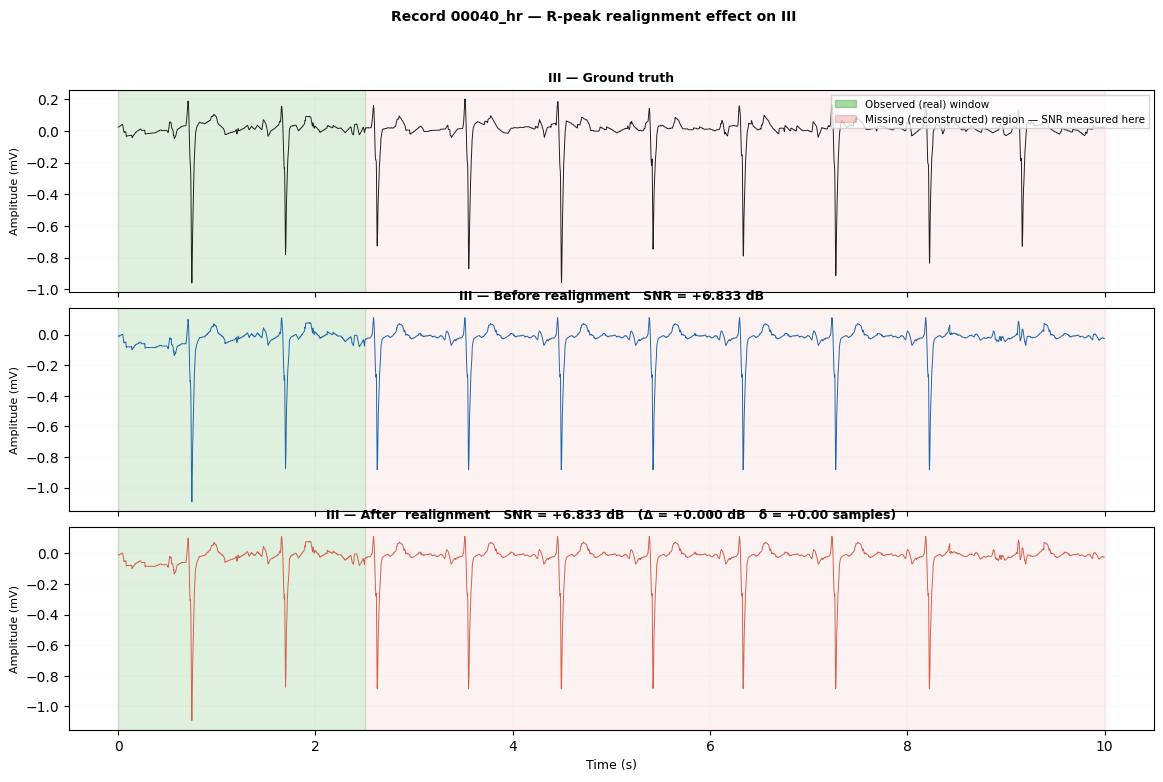


✅ Done. Realigned file: /Users/sinahassannia/Desktop/ecg_lead_cover2/realigned_ecg3/00000/00040_hr.npy


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Single-Record Test — δ + SNR before/after realignment + visualisation
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import wfdb
from ecg_utils import preprocess_data

GROUNDTRUTH_DIR = "/Users/sinahassannia/Desktop/ecg_lead_recovery/gt_clean"

TEST_RECORD     = "00040_hr"
TEST_REL_FOLDER = "00000"

# ── SNR helpers ───────────────────────────────────────────────────────────────
def _snr_db(x_true, x_est):
    err   = x_true - x_est
    P_sig = np.mean(x_true ** 2)
    P_err = np.mean(err ** 2)
    return np.inf if P_err < 1e-12 else 10 * np.log10(P_sig / P_err)

def snr_on_missing(x_true, x_est, lead, fs=FS):
    """SNR computed only on the reconstructed (missing) region."""
    obs_s, obs_e = get_observed_window(lead, fs)
    N    = len(x_true)
    mask = np.ones(N, dtype=bool)
    mask[obs_s:obs_e] = False        # True = missing region
    if mask.sum() == 0:
        return np.nan                # Lead II — nothing missing
    return _snr_db(x_true[mask], x_est[mask])

# ── Load ground truth ─────────────────────────────────────────────────────────
# def load_gt(record_name, gt_dir):
#     record_id  = int(record_name.split('_')[0])
#     folder_id  = (record_id - 1) // 1000 * 1000
#     hea_path   = Path(gt_dir) / f"{folder_id:05d}" / record_name
#     rec        = wfdb.rdrecord(str(hea_path))
#     X          = preprocess_data(rec.p_signal, rec.fs)   # (N, 12)
#     return X   # keep (N, 12) — matches .mat ecg convention

def load_gt(record_name: str, ecg_dir: str, selected_leads=["I", "II", "III", "AVR", "AVL", "AVF", "V1", "V2", "V3", "V4", "V5", "V6"]):
    record_id  = int(record_name.split('_')[0])
    folder_id  = (record_id - 1) // 1000 * 1000
    mat_path   = Path(ecg_dir) / f"{folder_id:05d}" / f"{record_name}.mat"

    data       = sio.loadmat(str(mat_path), squeeze_me=True)
    ecg        = data['ecg'].astype(np.float64)   # (N, 12)
    lead_names = list(data['lead_names'])

    if ecg.ndim == 2 and ecg.shape[0] < ecg.shape[1]:
        ecg = ecg.T

    if selected_leads is not None:
        available = {str(n).strip().lower(): (str(n), i) for i, n in enumerate(lead_names)}
        lead_indices, found_leads = [], []
        for req in selected_leads:
            key = req.strip().lower()
            if key in available:
                actual, idx = available[key]
                lead_indices.append(idx)
                found_leads.append(actual)
        ecg        = ecg[:, lead_indices]
        lead_names = found_leads

    return ecg

# ── Run realignment ───────────────────────────────────────────────────────────
print(f"Processing: {TEST_RECORD}\n")
deltas = compute_delta_and_realign(
    TEST_RECORD, TEST_REL_FOLDER,
    leads=ALL_LEADS, fs=FS,
    verbose=True
)

if deltas is None:
    print("\n❌ Failed — see errors above.")
else:
    # ── Load signals ──────────────────────────────────────────────────────────
    mat_path      = os.path.join(RECOVERED_MAT_DIR, TEST_REL_FOLDER, f"{TEST_RECORD}.mat")
    realigned_npy = os.path.join(REALIGNED_DIR,     TEST_REL_FOLDER, f"{TEST_RECORD}.npy")

    X_gt       = load_gt(TEST_RECORD, GROUNDTRUTH_DIR)                        # (N, 12)
    X_before   = sio.loadmat(mat_path, squeeze_me=True)['ecg'].astype(np.float64)  # (N, 12)
    X_after    = np.load(realigned_npy).astype(np.float64)                    # (N, 12)

    N = min(X_gt.shape[0], X_before.shape[0], X_after.shape[0])
    X_gt, X_before, X_after = X_gt[:N], X_before[:N], X_after[:N]

    # ── Compute SNR per lead ──────────────────────────────────────────────────
    snr_b = {}
    snr_a = {}
    for lead in ALL_LEADS:
        li        = ALL_LEADS.index(lead)
        snr_b[lead] = snr_on_missing(X_gt[:, li], X_before[:, li], lead)
        snr_a[lead] = snr_on_missing(X_gt[:, li], X_after [:, li], lead)

    # ── Print δ + SNR table ───────────────────────────────────────────────────
    print(f"\n── Results for {TEST_RECORD} ──")
    print(f"{'Lead':<6} {'Obs window':>12}  {'δ (samples)':>12}  {'δ (ms)':>8}  "
          f"{'SNR before':>11}  {'SNR after':>10}  {'ΔSNR':>7}")
    print("─" * 76)
    for lead in ALL_LEADS:
        d        = deltas[lead]
        obs_s, obs_e = get_observed_window(lead, FS)
        obs_str  = f"[{obs_s/FS:.1f}–{obs_e/FS:.1f}s]"
        sb       = snr_b[lead]
        sa       = snr_a[lead]
        dsnr     = sa - sb if np.isfinite(sa) and np.isfinite(sb) else np.nan
        flag     = " ✓" if (np.isfinite(dsnr) and dsnr >= 0) else (" –" if lead == 'II' else " ✗")
        print(f"  {lead:<4} {obs_str:>12}  {d:>+12.2f}  {d/FS*1000:>+8.1f}  "
              f"{sb:>+11.3f}  {sa:>+10.3f}  {dsnr:>+7.3f}{flag}")

    # ── Visualisation: all leads, before vs after ─────────────────────────────
    PLOT_LEAD = 'III'
    ch_idx    = ALL_LEADS.index(PLOT_LEAD)
    t         = np.arange(N) / FS
    obs_s, obs_e = get_observed_window(PLOT_LEAD, FS)

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    fig.subplots_adjust(hspace=0.08, top=0.88, bottom=0.08)

    signals = [X_gt[:, ch_idx], X_before[:, ch_idx], X_after[:, ch_idx]]
    colors  = ['#222222',       '#2166ac',            '#d6604d']
    titles  = [
        f"{PLOT_LEAD} — Ground truth",
        f"{PLOT_LEAD} — Before realignment   SNR = {snr_b[PLOT_LEAD]:+.3f} dB",
        f"{PLOT_LEAD} — After  realignment   SNR = {snr_a[PLOT_LEAD]:+.3f} dB   "
        f"(Δ = {snr_a[PLOT_LEAD]-snr_b[PLOT_LEAD]:+.3f} dB   δ = {deltas[PLOT_LEAD]:+.2f} samples)",
    ]

    for ax, sig, color, title in zip(axes, signals, colors, titles):
        ax.plot(t, sig, lw=0.7, color=color)
        ax.axvspan(obs_s/FS, obs_e/FS, alpha=0.15, color='#2ca02c', zorder=0)
        # shade missing region differently
        ax.axvspan(0,        obs_s/FS, alpha=0.06, color='#d62728', zorder=0)
        ax.axvspan(obs_e/FS, N/FS,     alpha=0.06, color='#d62728', zorder=0)
        ax.set_ylabel('Amplitude (mV)', fontsize=8)
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.grid(True, lw=0.3, alpha=0.4, linestyle=':')

    axes[-1].set_xlabel('Time (s)', fontsize=9)
    fig.suptitle(f'Record {TEST_RECORD} — R-peak realignment effect on {PLOT_LEAD}',
                 fontsize=10, fontweight='bold')

    legend_patches = [
        mpatches.Patch(color='#2ca02c', alpha=0.4, label='Observed (real) window'),
        mpatches.Patch(color='#d62728', alpha=0.2, label='Missing (reconstructed) region — SNR measured here'),
    ]
    axes[0].legend(handles=legend_patches, fontsize=7.5, loc='upper right',
                   frameon=True, edgecolor='#cccccc', fancybox=False)

    plt.savefig(os.path.join(REALIGNED_DIR, f"{TEST_RECORD}_{PLOT_LEAD}_realignment.png"),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Done. Realigned file: {realigned_npy}")

## 6. Batch Processing — Full Dataset

In [6]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import multiprocessing

# Discover all recovered .mat files
mat_files = sorted(Path(RECOVERED_MAT_DIR).rglob('*.mat'))
print(f"Found {len(mat_files):,} records to process.\n")

all_deltas_rows = []
n_ok   = 0
n_fail = 0

def process_single_mat(mat_path):
    record_name = mat_path.stem
    rel_folder  = os.path.relpath(str(mat_path.parent), RECOVERED_MAT_DIR)

    deltas = compute_delta_and_realign(
        record_name, rel_folder,
        leads=ALL_LEADS, fs=FS,
        verbose=False
    )

    if deltas is None:
        return None, record_name, rel_folder

    row = {'record': record_name, 'subfolder': rel_folder}
    for lead, d in deltas.items():
        row[f'delta_{lead}_samples'] = round(d, 4)
        row[f'delta_{lead}_ms']      = round(d / FS * 1000, 3)
    return row, record_name, rel_folder

N_WORKERS = multiprocessing.cpu_count()
print(f"Using {N_WORKERS} parallel workers.\n")

with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
    futures = {executor.submit(process_single_mat, p): p for p in mat_files}

    with tqdm(total=len(mat_files), desc="Realigning", unit="record") as pbar:
        for future in as_completed(futures):
            try:
                row, record_name, rel_folder = future.result()
                if row is None:
                    n_fail += 1
                else:
                    n_ok += 1
                    all_deltas_rows.append(row)
            except Exception as e:
                n_fail += 1
                print(f"\n⚠️  Exception on {futures[future].stem}: {e}")
            finally:
                pbar.update(1)

print(f"\n✅ OK: {n_ok:,}   ❌ Failed: {n_fail:,}")

Found 20,624 records to process.

Using 14 parallel workers.



Realigning: 100%|██████████| 20624/20624 [00:22<00:00, 913.50record/s] 


✅ OK: 20,624   ❌ Failed: 0


Computing SNR: 100%|██████████| 20624/20624 [00:50<00:00, 404.40record/s]



✅ SNR computed: 20,624   ❌ Skipped: 0


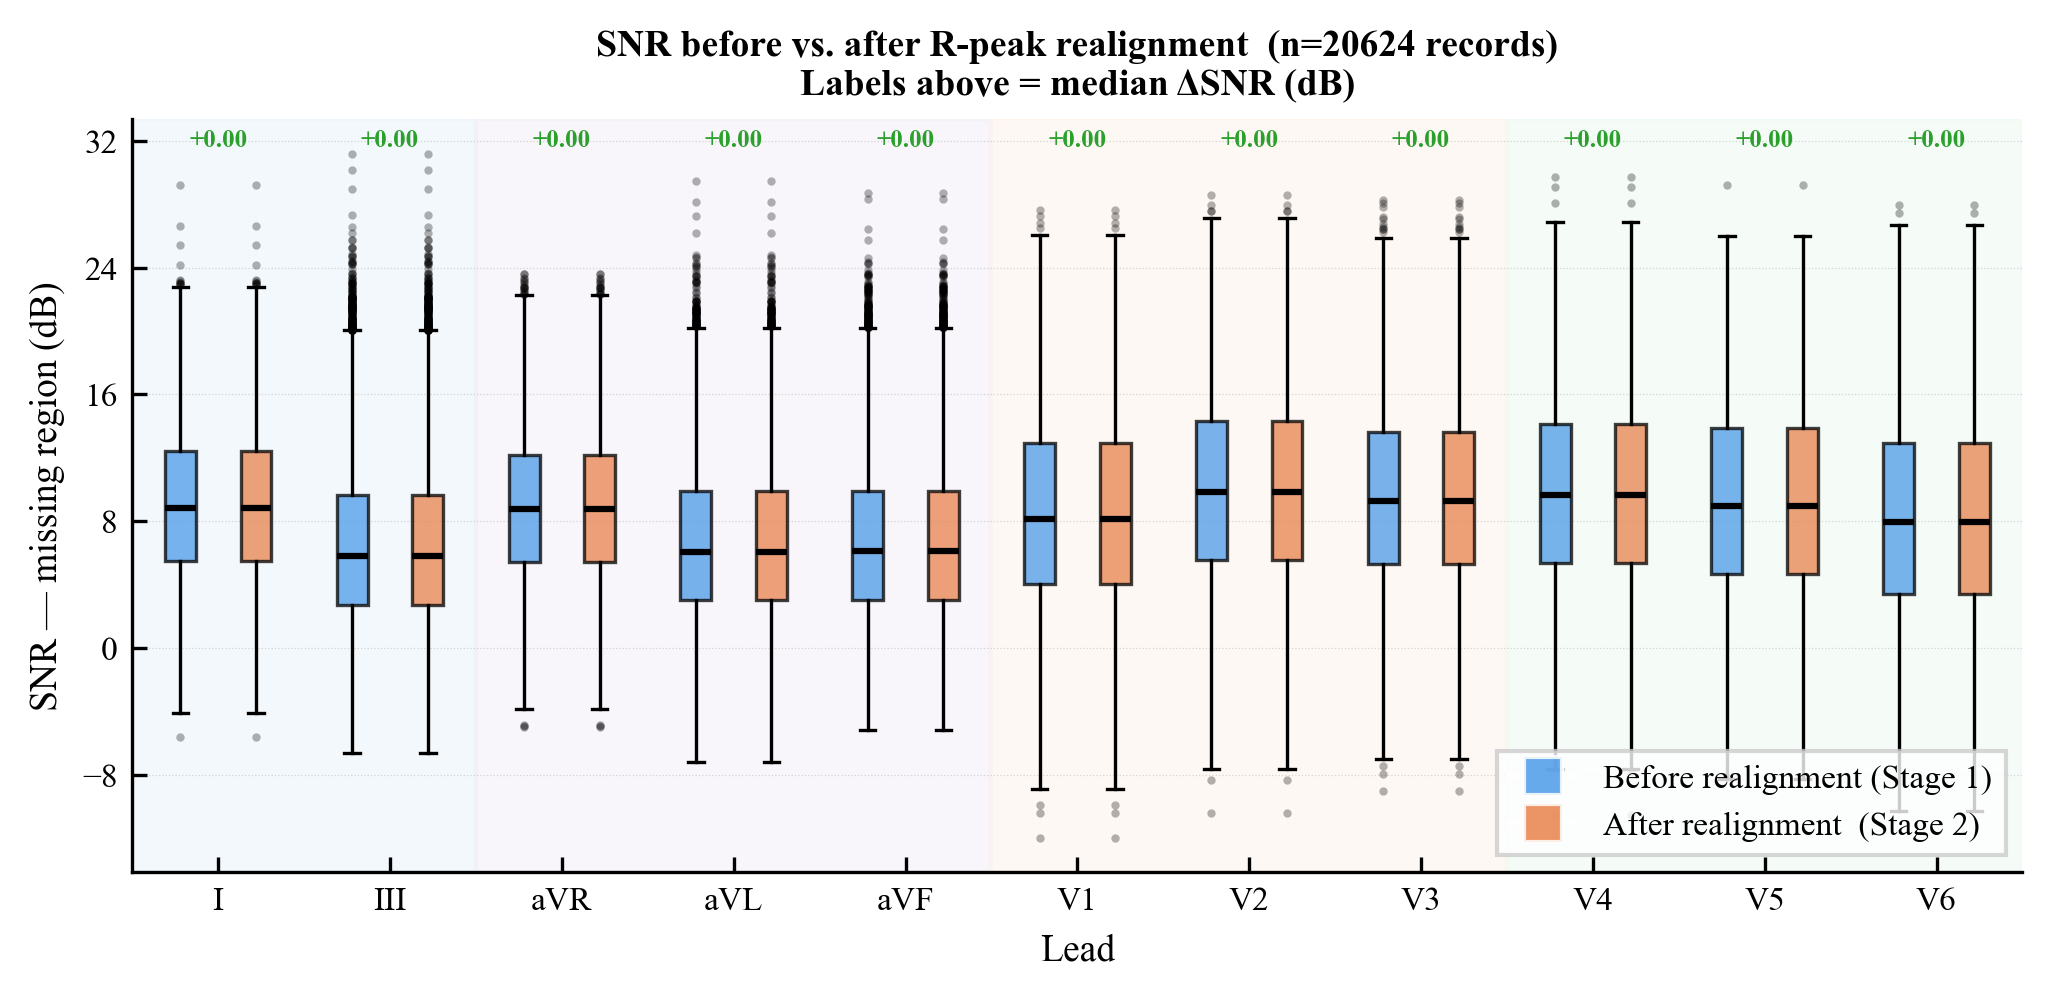


Lead       N   Med before   Med after   Δ median   % improved
──────────────────────────────────────────────────────────
  I    20624       +8.870      +8.870     +0.000         0.0%
  III  20624       +5.840      +5.840     +0.000         0.0%
  aVR  20624       +8.755      +8.755     +0.000         0.0%
  aVL  20624       +6.088      +6.088     +0.000         0.0%
  aVF  20624       +6.123      +6.123     +0.000         0.0%
  V1   20624       +8.175      +8.175     +0.000         0.0%
  V2   20624       +9.858      +9.858     +0.000         0.0%
  V3   20624       +9.304      +9.304     +0.000         0.0%
  V4   20624       +9.638      +9.638     +0.000         0.0%
  V5   20624       +8.987      +8.987     +0.000         0.0%
  V6   20624       +7.945      +7.945     +0.000         0.0%


In [7]:
# ── 2a. load_ecg ───────────────────────────────────────────────────────────

def load_ecg(record_path,
             selected_leads=['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                             'V1', 'V2', 'V3', 'V4', 'V5', 'V6']):
    """
    Load ECG from a .mat file.
    Returns (signal (N, num_leads), record) where record has .sig_name / .fs / .record_name.
    """
    if record_path.endswith('.mat'):
        record_path = record_path[:-4]

    data       = sio.loadmat(record_path + '.mat', squeeze_me=True)
    ecg        = data['ecg'].astype(np.float64)
    lead_names = list(data['lead_names'])

    if ecg.ndim == 2 and ecg.shape[0] < ecg.shape[1]:
        ecg = ecg.T   # ensure (N, leads)

    if selected_leads is not None:
        available = {str(n).strip().lower(): (str(n), i)
                     for i, n in enumerate(lead_names)}
        lead_indices, found_leads = [], []
        for req in selected_leads:
            key = req.strip().lower()
            if key in available:
                actual, idx = available[key]
                lead_indices.append(idx)
                found_leads.append(actual)
            else:
                print(f"⚠️  Lead '{req}' not found. Available: {lead_names}")
        if not lead_indices:
            print("ERROR: No requested leads found!")
            return None, None
        ecg        = ecg[:, lead_indices]
        lead_names = found_leads

    class Record:
        def __init__(self, sig_name, fs, record_name):
            self.sig_name    = sig_name
            self.fs          = fs
            self.record_name = record_name

    record = Record(
        sig_name    = lead_names,
        fs          = float(data['fs']),
        record_name = str(data['record_name']),
    )
    return ecg, record


# ─────────────────────────────────────────────────────────────────────────────
# Batch SNR collection + box plot — before vs after realignment
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import wfdb
from ecg_utils import preprocess_data

plt.rcParams.update({
    'font.family'        : 'serif',
    'font.serif'         : ['Times New Roman', 'DejaVu Serif'],
    'font.size'          : 9,
    'axes.titlesize'     : 9,
    'axes.labelsize'     : 9,
    'xtick.labelsize'    : 8,
    'ytick.labelsize'    : 8,
    'axes.linewidth'     : 0.8,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'xtick.direction'    : 'in',
    'ytick.direction'    : 'in',
    'figure.dpi'         : 300,
    'savefig.dpi'        : 300,
    'pdf.fonttype'       : 42,
    'ps.fonttype'        : 42,
})


GROUNDTRUTH_DIR = "/Users/sinahassannia/Desktop/ecg_lead_cover2/gt_clean"
LEADS_NO_II     = [l for l in ALL_LEADS if l != 'II']

# ── Helpers ───────────────────────────────────────────────────────────────────
def _snr_db(x_true, x_est):
    err   = x_true - x_est
    P_sig = np.mean(x_true ** 2)
    P_err = np.mean(err ** 2)
    return np.nan if P_err < 1e-12 else 10 * np.log10(P_sig / P_err)

def snr_on_missing(x_true, x_est, lead, fs=FS):
    obs_s, obs_e = get_observed_window(lead, fs)
    mask = np.ones(len(x_true), dtype=bool)
    mask[obs_s:obs_e] = False
    if mask.sum() == 0:
        return np.nan
    return _snr_db(x_true[mask], x_est[mask])

def load_gt(record_name, gt_dir):
    record_id = int(record_name.split('_')[0])
    folder_id = (record_id - 1) // 1000 * 1000
    hea_path  = Path(gt_dir) / f"{folder_id:05d}" / record_name
    rec       = wfdb.rdrecord(str(hea_path))
    return preprocess_data(rec.p_signal, rec.fs)   # (N, 12)

# ── Collect SNRs ──────────────────────────────────────────────────────────────
snr_before = {l: [] for l in LEADS_NO_II}
snr_after  = {l: [] for l in LEADS_NO_II}
n_snr_ok   = 0
n_snr_fail = 0

for row in tqdm(all_deltas_rows, desc="Computing SNR", unit="record"):
    record_name = row['record']
    rel_folder  = row['subfolder']

    gt_path = os.path.join(GROUNDTRUTH_DIR, rel_folder, f"{record_name}.mat")
    mat_path      = os.path.join(RECOVERED_MAT_DIR, rel_folder, f"{record_name}.mat")
    realigned_npy = os.path.join(REALIGNED_DIR,     rel_folder, f"{record_name}.npy")

    if not os.path.exists(realigned_npy):
        n_snr_fail += 1
        continue

    try:
        X_gt, record  = load_ecg(gt_path)
        X_before = sio.loadmat(mat_path, squeeze_me=True)['ecg'].astype(np.float64)
        X_after  = np.load(realigned_npy).astype(np.float64)
    except Exception:
        n_snr_fail += 1
        continue

    N = min(X_gt.shape[0], X_before.shape[0], X_after.shape[0])
    X_gt, X_before, X_after = X_gt[:N], X_before[:N], X_after[:N]

    for lead in LEADS_NO_II:
        li  = ALL_LEADS.index(lead)
        sb  = snr_on_missing(X_gt[:, li], X_before[:, li], lead)
        sa  = snr_on_missing(X_gt[:, li], X_after [:, li], lead)
        if np.isfinite(sb) and np.isfinite(sa):
            snr_before[lead].append(sb)
            snr_after [lead].append(sa)

    n_snr_ok += 1

print(f"\n✅ SNR computed: {n_snr_ok:,}   ❌ Skipped: {n_snr_fail:,}")

# ── Box plot ──────────────────────────────────────────────────────────────────
n_leads  = len(LEADS_NO_II)
x        = np.arange(n_leads)
offset   = 0.22

fig, ax = plt.subplots(figsize=(7.16, 3.8))
fig.subplots_adjust(left=0.09, right=0.97, top=0.84, bottom=0.18)

BP_PROPS = dict(
    patch_artist  = True,
    showfliers    = True,
    flierprops    = dict(marker='.', markersize=2, alpha=0.3, lw=0),
    medianprops   = dict(lw=1.5, color='black'),
    whiskerprops  = dict(lw=0.8),
    capprops      = dict(lw=0.8),
    boxprops      = dict(lw=0.8),
    widths        = 0.18,
)

# before
bp_b = ax.boxplot(
    [snr_before[l] for l in LEADS_NO_II],
    positions = x - offset,
    **BP_PROPS
)
for patch in bp_b['boxes']:
    patch.set_facecolor('#4C9BE8')
    patch.set_alpha(0.75)

# after
bp_a = ax.boxplot(
    [snr_after[l] for l in LEADS_NO_II],
    positions = x + offset,
    **BP_PROPS
)
for patch in bp_a['boxes']:
    patch.set_facecolor('#E8834C')
    patch.set_alpha(0.75)

# ΔSNR median annotation above each pair
for i, lead in enumerate(LEADS_NO_II):
    med_b = np.median(snr_before[lead])
    med_a = np.median(snr_after [lead])
    delta = med_a - med_b
    col   = '#2ca02c' if delta >= 0 else '#d62728'
    ax.text(x[i], ax.get_ylim()[1] * 0.98,
            f'{delta:+.2f}',
            ha='center', va='top', fontsize=6,
            color=col, fontweight='bold')

# Lead-group background shading
group_spans = [
    ((-0.5,  1.5), '#EAF4FB'),   # I, III
    (( 1.5,  4.5), '#F3EEF9'),   # aVR, aVL, aVF
    (( 4.5,  7.5), '#FEF3EC'),   # V1–V3
    (( 7.5, 10.5), '#EDFBF1'),   # V4–V6
]
for (x0, x1), c in group_spans:
    ax.axvspan(x0, x1, color=c, alpha=0.55, zorder=0)

ax.set_xticks(x)
ax.set_xticklabels(LEADS_NO_II)
ax.set_xlim(-0.5, n_leads - 0.5)
ax.set_ylabel('SNR — missing region (dB)', fontsize=9)
ax.set_xlabel('Lead', fontsize=9)
ax.set_title(
    f'SNR before vs. after R-peak realignment  (n={n_snr_ok} records)\n'
    'Labels above = median ΔSNR (dB)',
    fontsize=9, fontweight='bold'
)
ax.yaxis.set_major_locator(ticker.MaxNLocator(6))
ax.grid(True, axis='y', lw=0.3, alpha=0.5, linestyle=':')

legend_elements = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#4C9BE8',
           markersize=9, alpha=0.85, label='Before realignment (Stage 1)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#E8834C',
           markersize=9, alpha=0.85, label='After realignment  (Stage 2)'),
]
ax.legend(handles=legend_elements, fontsize=8, frameon=True,
          edgecolor='#cccccc', fancybox=False, loc='lower right')

plt.savefig(os.path.join(REALIGNED_DIR, 'snr_boxplot_before_after.pdf'),
            bbox_inches='tight', format='pdf')
plt.savefig(os.path.join(REALIGNED_DIR, 'snr_boxplot_before_after.png'),
            bbox_inches='tight', dpi=300)
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Lead':<6} {'N':>5}  {'Med before':>11}  {'Med after':>10}  "
      f"{'Δ median':>9}  {'% improved':>11}")
print("─" * 58)
for lead in LEADS_NO_II:
    sb   = np.array(snr_before[lead])
    sa   = np.array(snr_after [lead])
    pct  = 100 * np.mean(sa > sb)
    print(f"  {lead:<4} {len(sb):>5}  {np.median(sb):>+11.3f}  "
          f"{np.median(sa):>+10.3f}  "
          f"{np.median(sa)-np.median(sb):>+9.3f}  {pct:>10.1f}%")

## 7. Save & Inspect Summary CSV

In [8]:
df_summary = pd.DataFrame(all_deltas_rows)
df_summary.to_csv(SUMMARY_CSV, index=False)
print(f"Saved → {SUMMARY_CSV}")
print(f"Shape  : {df_summary.shape}")
display(df_summary.head(50))

Saved → /Users/sinahassannia/Desktop/ecg_lead_cover2/rpeak_delta_summary3.csv
Shape  : (20624, 26)


,record,subfolder,delta_I_samples,delta_I_ms,delta_II_samples,delta_II_ms,delta_III_samples,delta_III_ms,delta_aVR_samples,delta_aVR_ms,...,delta_V2_samples,delta_V2_ms,delta_V3_samples,delta_V3_ms,delta_V4_samples,delta_V4_ms,delta_V5_samples,delta_V5_ms,delta_V6_samples,delta_V6_ms
0,00001_hr,00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,00003_hr,00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,00006_hr,00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,00009_hr,00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,00013_hr,00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,00004_hr,00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,00014_hr,00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,00002_hr,00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,00010_hr,00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,00005_hr,00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 8. Dataset-level δ Statistics

In [9]:
sample_cols = [c for c in df_summary.columns if c.startswith('delta_') and c.endswith('_samples')]

stats = []
for col in sample_cols:
    lead = col.replace('delta_', '').replace('_samples', '')
    if lead.upper() == 'II':
        continue
    vals = df_summary[col].dropna()
    obs_start, obs_end = get_observed_window(lead, FS)
    stats.append({
        'Lead'          : lead,
        'Observed window': f"{obs_start/FS:.1f}–{obs_end/FS:.1f}s",
        'N records'     : len(vals),
        'Mean δ (ms)'   : round(vals.mean()  / FS * 1000, 3),
        'Std δ (ms)'    : round(vals.std()   / FS * 1000, 3),
        'Median δ (ms)' : round(vals.median()/ FS * 1000, 3),
        'Max |δ| (ms)'  : round(vals.abs().max() / FS * 1000, 3),
        '|δ| > 1 sample': int((vals.abs() >= 1.0).sum()),
    })

df_stats = pd.DataFrame(stats).set_index('Lead')
print(df_stats.to_string())

     Observed window  N records  Mean δ (ms)  Std δ (ms)  Median δ (ms)  Max |δ| (ms)  |δ| > 1 sample
Lead                                                                                                 
I           0.0–2.5s      20624          0.0         0.0            0.0           0.0               0
III         0.0–2.5s      20624          0.0         0.0            0.0           0.0               0
aVR         2.5–5.0s      20624          0.0         0.0            0.0           0.0               0
aVL         2.5–5.0s      20624          0.0         0.0            0.0           0.0               0
aVF         2.5–5.0s      20624          0.0         0.0            0.0           0.0               0
V1          5.0–7.5s      20624          0.0         0.0            0.0           0.0               0
V2          5.0–7.5s      20624          0.0         0.0            0.0           0.0               0
V3          5.0–7.5s      20624          0.0         0.0            0.0           

## 9. δ Distribution Plot

/var/folders/vc/8z0y3p692pjcv1x3wndz_g2w0000gn/T/ipykernel_3321/1117984985.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_ms, labels=leads_to_plot, patch_artist=True,


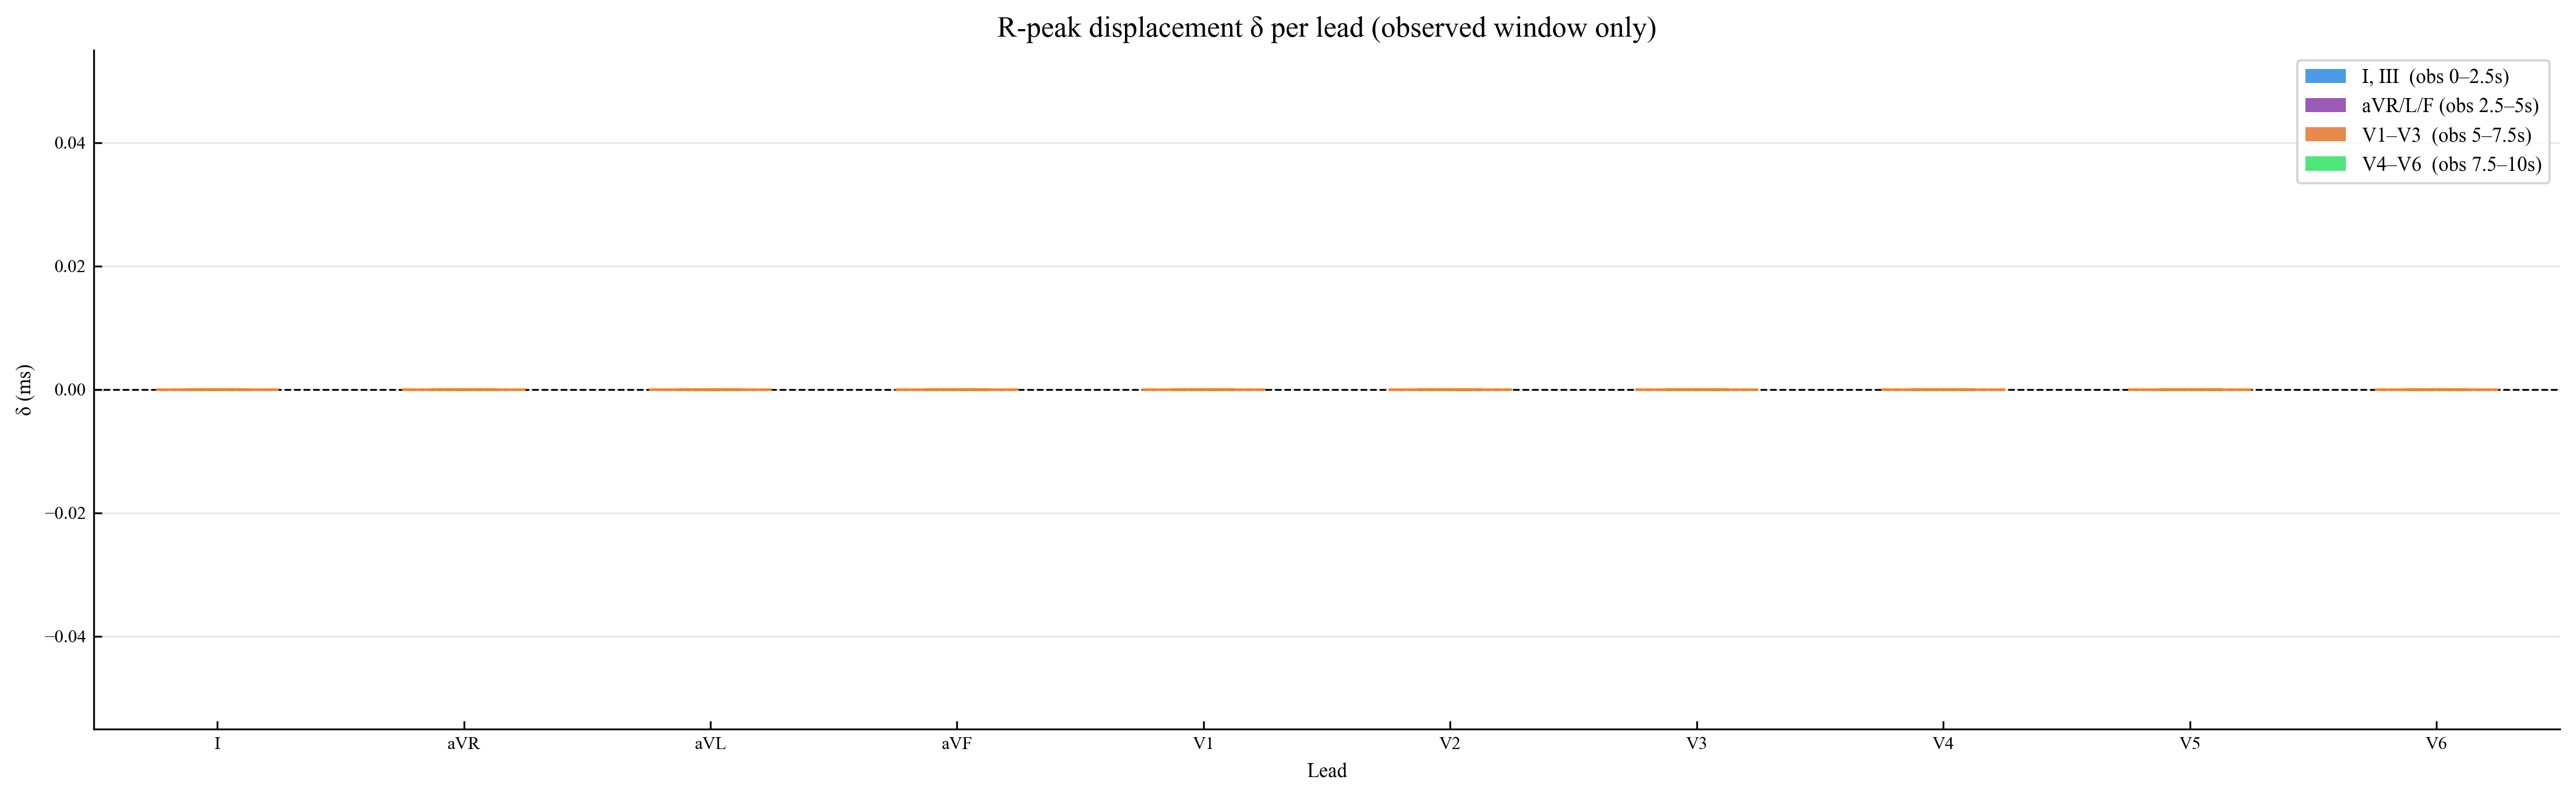

Saved → rpeak_delta_distribution.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

leads_to_plot = [c.replace('delta_','').replace('_samples','') 
                 for c in sample_cols 
                 if 'II' not in c]

data_ms = [df_summary[f'delta_{l}_samples'].dropna().values / FS * 1000
           for l in leads_to_plot]

# Colour by lead group
color_map = {
    'I':'#4C9BE8', 'III':'#4C9BE8',
    'aVR':'#9B59B6','aVL':'#9B59B6','aVF':'#9B59B6',
    'V1':'#E88A4C','V2':'#E88A4C','V3':'#E88A4C',
    'V4':'#4CE87A','V5':'#4CE87A','V6':'#4CE87A',
}
colors = [color_map.get(l, 'gray') for l in leads_to_plot]

fig, ax = plt.subplots(figsize=(16, 5))
bp = ax.boxplot(data_ms, labels=leads_to_plot, patch_artist=True,
                showfliers=True, flierprops=dict(marker='.', markersize=2, alpha=0.4))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.axhline(0, color='black', lw=0.8, ls='--', label='δ = 0')
ax.set_title('R-peak displacement δ per lead (observed window only)', fontsize=13)
ax.set_xlabel('Lead')
ax.set_ylabel('δ (ms)')
ax.grid(True, alpha=0.3, axis='y')

legend_patches = [
    mpatches.Patch(facecolor='#4C9BE8', label='I, III  (obs 0–2.5s)'),
    mpatches.Patch(facecolor='#9B59B6', label='aVR/L/F (obs 2.5–5s)'),
    mpatches.Patch(facecolor='#E88A4C', label='V1–V3  (obs 5–7.5s)'),
    mpatches.Patch(facecolor='#4CE87A', label='V4–V6  (obs 7.5–10s)'),
]
ax.legend(handles=legend_patches, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig("rpeak_delta_distribution.png", dpi=150)
plt.show()
print("Saved → rpeak_delta_distribution.png")